# Regularization methods

I wanted to revisit ridge and lasso with a current dataset. Instead of the old Boston-style example, I use diabetes data and create extra polynomial features so overfitting is easier to notice.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

## 1. Prepare the data

I keep the split first, then fit the polynomial expansion and scaling on the training data only. That keeps the regularization comparison clean and avoids leakage from the test set.

In [2]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# The expanded feature space makes ordinary least squares less stable.
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Ridge and lasso depend on feature scale, so I standardize after expansion.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

feature_names = poly.get_feature_names_out(X.columns)

print(f"Original features: {X.shape[1]}")
print(f"Expanded features: {X_train_scaled.shape[1]}")
pd.DataFrame(X_train.iloc[:5]).round(3)

Original features: 10
Expanded features: 65


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
17,0.071,0.051,0.012,0.056,0.034,0.049,-0.040,0.034,0.027,-0.001
66,-0.009,0.051,-0.018,-0.033,-0.021,0.012,-0.073,0.071,0.000,0.020
137,0.005,-0.045,0.050,0.098,-0.015,-0.016,-0.007,-0.003,0.017,-0.014
245,-0.027,-0.045,-0.035,-0.030,-0.057,-0.059,0.030,-0.039,-0.050,-0.129
31,-0.024,-0.045,-0.065,-0.081,-0.039,-0.054,0.060,-0.076,-0.037,-0.042


## 2. Linear regression baseline

I start with no regularization so I have something to compare against. With many correlated polynomial terms, I expect the train score to look a bit too optimistic.

In [3]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_train_pred = linear_model.predict(X_train_scaled)
linear_test_pred = linear_model.predict(X_test_scaled)

baseline_results = pd.DataFrame({
    "Model": ["Linear regression"],
    "Train R^2": [r2_score(y_train, linear_train_pred)],
    "Test R^2": [r2_score(y_test, linear_test_pred)],
    "Test RMSE": [mean_squared_error(y_test, linear_test_pred) ** 0.5],
    "Test MAE": [mean_absolute_error(y_test, linear_test_pred)],
})
baseline_results.round(3)

,Model,Train R^2,Test R^2,Test RMSE,Test MAE
0,Linear regression,0.606,0.416,55.642,43.582


## 3. Ridge regression

Ridge keeps every feature but shrinks the coefficients toward zero. I want to see whether a stronger penalty improves the test score after the polynomial expansion.

In [4]:
ridge_alphas = [0.1, 1, 10, 100]
ridge_models = {}
ridge_rows = []

for alpha in ridge_alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    ridge_models[alpha] = model
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    ridge_rows.append({
        "Model": f"Ridge (alpha={alpha})",
        "Train R^2": r2_score(y_train, train_pred),
        "Test R^2": r2_score(y_test, test_pred),
        "Test RMSE": mean_squared_error(y_test, test_pred) ** 0.5,
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Non-zero coefficients": int(np.sum(np.abs(model.coef_) > 1e-8)),
    })

ridge_results = pd.DataFrame(ridge_rows).sort_values("Test R^2", ascending=False)
ridge_results.round(3)

,Model,Train R^2,Test R^2,Test RMSE,Test MAE,Non-zero coefficients
2,Ridge (alpha=10),0.590,0.503,51.314,39.867,65
3,Ridge (alpha=100),0.561,0.498,51.567,41.573,65
1,Ridge (alpha=1),0.601,0.456,53.697,41.714,65
0,Ridge (alpha=0.1),0.604,0.421,55.380,42.786,65


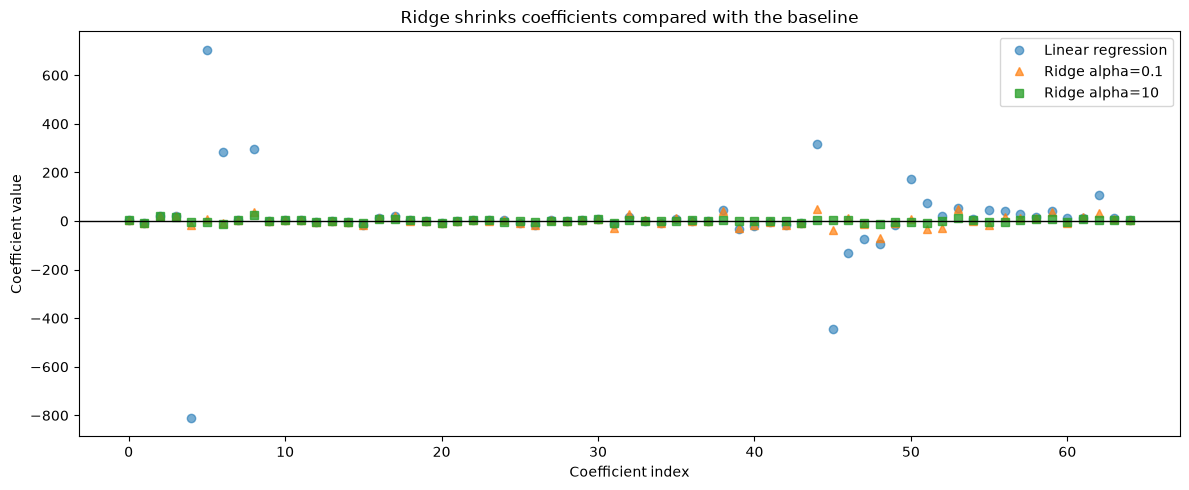

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(linear_model.coef_, "o", label="Linear regression", alpha=0.6)
plt.plot(ridge_models[0.1].coef_, "^", label="Ridge alpha=0.1", alpha=0.7)
plt.plot(ridge_models[10].coef_, "s", label="Ridge alpha=10", alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient value")
plt.title("Ridge shrinks coefficients compared with the baseline")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Lasso regression

Lasso can both shrink and remove coefficients. I use a larger `max_iter` because weaker penalties usually need more optimization steps before they settle.

In [6]:
lasso_alphas = [0.01, 0.1, 1, 5]
lasso_models = {}
lasso_rows = []

for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_train_scaled, y_train)
    lasso_models[alpha] = model
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    lasso_rows.append({
        "Model": f"Lasso (alpha={alpha})",
        "Train R^2": r2_score(y_train, train_pred),
        "Test R^2": r2_score(y_test, test_pred),
        "Test RMSE": mean_squared_error(y_test, test_pred) ** 0.5,
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Non-zero coefficients": int(np.sum(np.abs(model.coef_) > 1e-8)),
    })

lasso_results = pd.DataFrame(lasso_rows).sort_values("Test R^2", ascending=False)
lasso_results.round(3)

,Model,Train R^2,Test R^2,Test RMSE,Test MAE,Non-zero coefficients
2,Lasso (alpha=1),0.567,0.516,50.635,40.038,36
3,Lasso (alpha=5),0.510,0.488,52.067,42.784,12
1,Lasso (alpha=0.1),0.597,0.479,52.549,40.495,54
0,Lasso (alpha=0.01),0.604,0.422,55.348,42.724,62


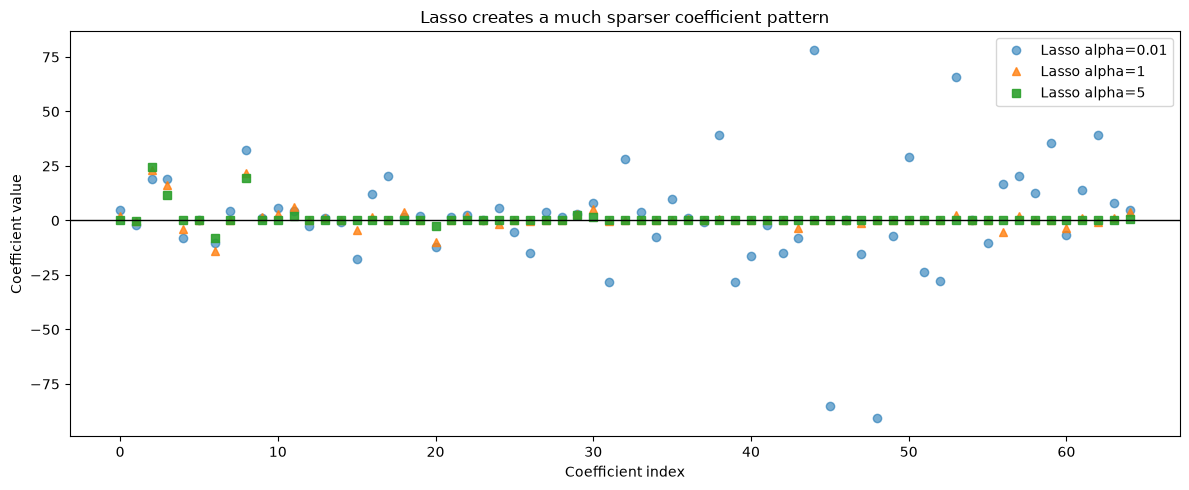

,alpha,non_zero_coefficients
0,0.01,62
1,0.10,54
2,1.00,36
3,5.00,12


In [7]:
plt.figure(figsize=(12, 5))
plt.plot(lasso_models[0.01].coef_, "o", label="Lasso alpha=0.01", alpha=0.6)
plt.plot(lasso_models[1].coef_, "^", label="Lasso alpha=1", alpha=0.8)
plt.plot(lasso_models[5].coef_, "s", label="Lasso alpha=5", alpha=0.9)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient value")
plt.title("Lasso creates a much sparser coefficient pattern")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    "alpha": lasso_alphas,
    "non_zero_coefficients": [int(np.sum(np.abs(lasso_models[a].coef_) > 1e-8)) for a in lasso_alphas],
}).sort_values("alpha")

## 5. Compare the best regularized models

After the tables, I want one direct look at the predictions. If the regularized models track the diagonal more closely than the baseline, the penalty is helping generalization.

In [8]:
comparison = pd.concat([baseline_results, ridge_results, lasso_results], ignore_index=True)
comparison = comparison.sort_values("Test R^2", ascending=False).reset_index(drop=True)
comparison.round(3)

,Model,Train R^2,Test R^2,Test RMSE,Test MAE,Non-zero coefficients
0,Lasso (alpha=1),0.567,0.516,50.635,40.038,36.0
1,Ridge (alpha=10),0.590,0.503,51.314,39.867,65.0
2,Ridge (alpha=100),0.561,0.498,51.567,41.573,65.0
3,Lasso (alpha=5),0.510,0.488,52.067,42.784,12.0
4,Lasso (alpha=0.1),0.597,0.479,52.549,40.495,54.0
5,Ridge (alpha=1),0.601,0.456,53.697,41.714,65.0
6,Lasso (alpha=0.01),0.604,0.422,55.348,42.724,62.0
7,Ridge (alpha=0.1),0.604,0.421,55.380,42.786,65.0
8,Linear regression,0.606,0.416,55.642,43.582,NaN


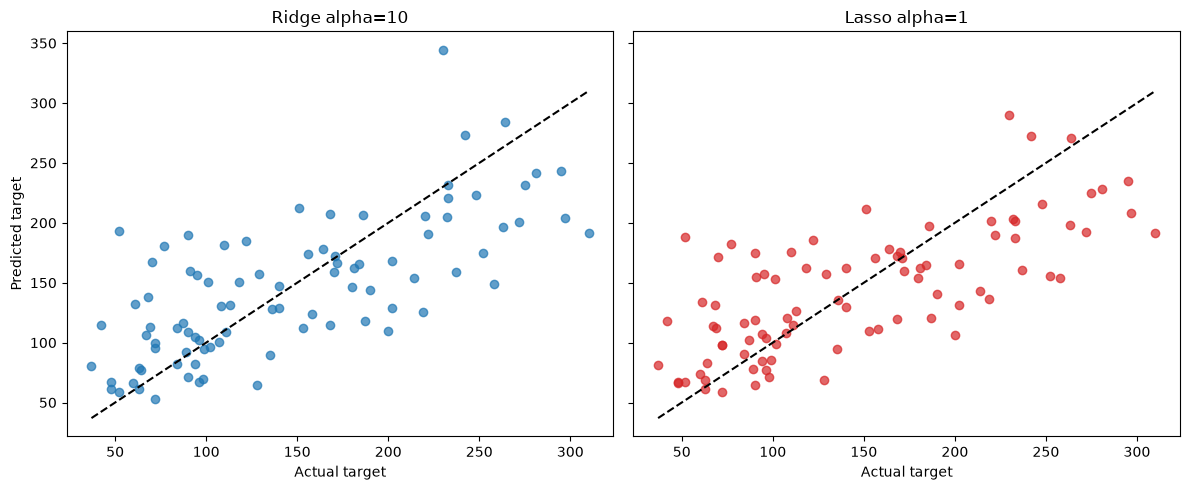

In [9]:
best_ridge = ridge_models[10]
best_lasso = lasso_models[1]

best_ridge_pred = best_ridge.predict(X_test_scaled)
best_lasso_pred = best_lasso.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(y_test, best_ridge_pred, alpha=0.7, color="#1f77b4")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[0].set_title("Ridge alpha=10")
axes[0].set_xlabel("Actual target")
axes[0].set_ylabel("Predicted target")

axes[1].scatter(y_test, best_lasso_pred, alpha=0.7, color="#d62728")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[1].set_title("Lasso alpha=1")
axes[1].set_xlabel("Actual target")

plt.tight_layout()
plt.show()

## What I learned

- The unregularized model reached train/test R^2 of 0.606/0.416, so the polynomial features made overfitting visible.
- Ridge with `alpha=10` raised the test R^2 to 0.503 while keeping all 65 expanded features.
- Lasso with `alpha=1` did a bit better at 0.516 and kept only 36 coefficients.
- A stronger lasso penalty (`alpha=5`) dropped the model to 12 coefficients and still stayed near 0.488 test R^2, so sparsity did not cost too much here.